# AnalystLab Africa Data Science Internship

## Week 3: Statistics & Probability

### Student Name: Brian Odhiambo

### Dataset 1: Titanic Dataset
### Dataset 2: Housing Price Dataset


## Introduction

This notebook presents the statistical analysis of two cleaned datasets:

1. Titanic Dataset – used to investigate factors influencing passenger survival.
2. Housing Price Dataset – used to analyze factors affecting house prices.

The analysis covers:

- Descriptive Statistics
- Probability Distributions
- Hypothesis Testing
- Correlation Analysis
- Statistical Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load datasets
titanic = pd.read_csv("cleaned_titanic.csv")
housing = pd.read_csv("cleaned_housing.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


# Task 1: Descriptive Statistics

Descriptive statistics summarize the main characteristics of a dataset.

The following measures are analyzed:

- Mean
- Median
- Standard Deviation
- Variance

In [3]:
print("========== TITANIC DATASET ==========")
print(titanic.describe())

print("\nTitanic Age Statistics")
print("Mean:", titanic["Age"].mean())
print("Median:", titanic["Age"].median())
print("Standard Deviation:", titanic["Age"].std())
print("Variance:", titanic["Age"].var())

print("\n========== HOUSING DATASET ==========")
print(housing.describe())

print("\nHousing Price Statistics")
print("Mean:", housing["price"].mean())
print("Median:", housing["price"].median())
print("Standard Deviation:", housing["price"].std())
print("Variance:", housing["price"].var())

========== TITANIC DATASET ==========
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Titanic Age Statistics
Mean: 29.3615824915

# Statistical Interpretation

### Titanic Dataset

- Average passenger age is approximately 29 years.
- The age distribution shows moderate variability.
- The variance indicates that ages are spread across different age groups.

### Housing Dataset

- Average house price is approximately 4.77 million.
- Housing prices show high variability.
- The large variance suggests significant differences between low-priced and high-priced properties.

# Probability Distribution

Probability distributions describe how values are distributed within a dataset.

In this analysis:

- Titanic Dataset: Distribution of passenger ages.
- Housing Dataset: Distribution of house prices.

Histograms are used to visualize the distribution of numerical variables and identify patterns such as skewness, spread, and concentration of values.

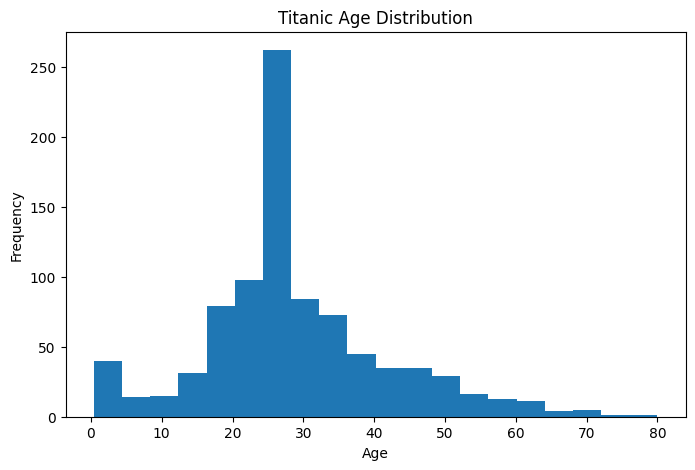

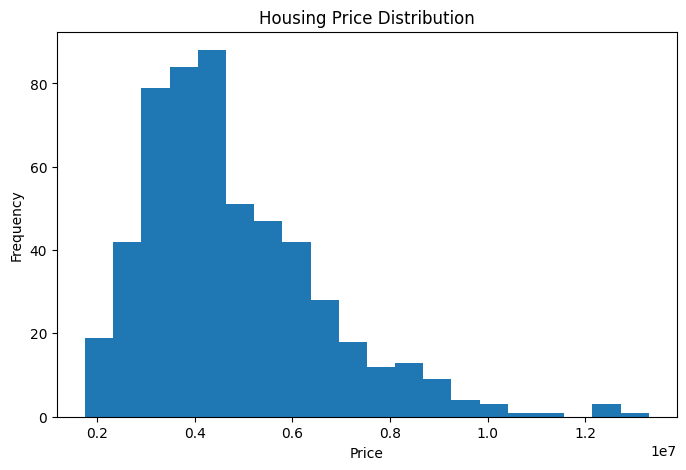

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned datasets
titanic = pd.read_csv("cleaned_titanic.csv")
housing = pd.read_csv("cleaned_housing.csv")

# Titanic Age Distribution
plt.figure(figsize=(8,5))
plt.hist(titanic["Age"], bins=20)
plt.title("Titanic Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Housing Price Distribution
plt.figure(figsize=(8,5))
plt.hist(housing["price"], bins=20)
plt.title("Housing Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Interpretation

### Titanic Dataset
- Most passengers were between 20 and 40 years old.
- The age distribution is slightly right-skewed.
- Few passengers were older than 60 years.

### Housing Dataset
- Most house prices are concentrated between 3 million and 6 million.
- The distribution is positively skewed.
- A few expensive houses create a long right tail.

The Z-score measures how many standard deviations a value is from the mean. It is useful for identifying unusual observations and outliers in a dataset.

# Correlation vs Causation

Correlation measures the strength and direction of a relationship between two variables.

Causation means that one variable directly affects another.

A strong correlation does not necessarily imply causation. Two variables may move together due to coincidence or because they are both influenced by another factor.

This section examines correlations within the Titanic and Housing datasets.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
titanic = pd.read_csv("cleaned_titanic.csv")
housing = pd.read_csv("cleaned_housing.csv")

# Titanic correlation matrix
titanic_corr = titanic[["Survived","Age","Fare","Pclass","SibSp","Parch"]].corr()

print("TITANIC CORRELATION MATRIX")
print(titanic_corr)

# Housing correlation matrix
housing_corr = housing[["price","area","bedrooms","bathrooms","stories","parking"]].corr()

print("\nHOUSING CORRELATION MATRIX")
print(housing_corr)

TITANIC CORRELATION MATRIX
          Survived       Age      Fare    Pclass     SibSp     Parch
Survived  1.000000 -0.064910  0.257307 -0.338481 -0.035322  0.081629
Age      -0.064910  1.000000  0.096688 -0.339898 -0.233296 -0.172482
Fare      0.257307  0.096688  1.000000 -0.549500  0.159651  0.216225
Pclass   -0.338481 -0.339898 -0.549500  1.000000  0.083081  0.018443
SibSp    -0.035322 -0.233296  0.159651  0.083081  1.000000  0.414838
Parch     0.081629 -0.172482  0.216225  0.018443  0.414838  1.000000

HOUSING CORRELATION MATRIX
              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139

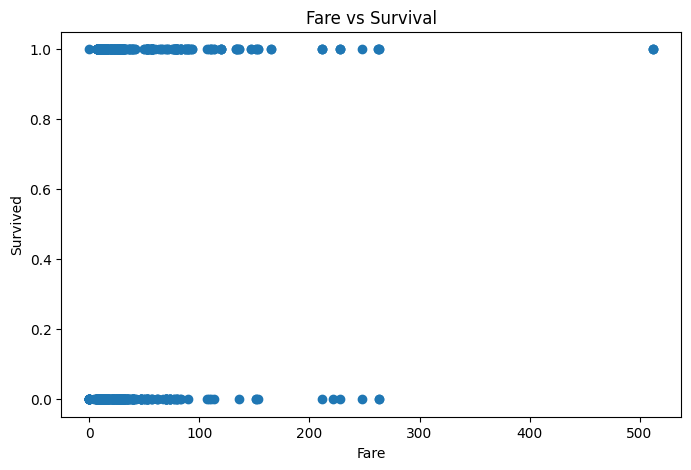

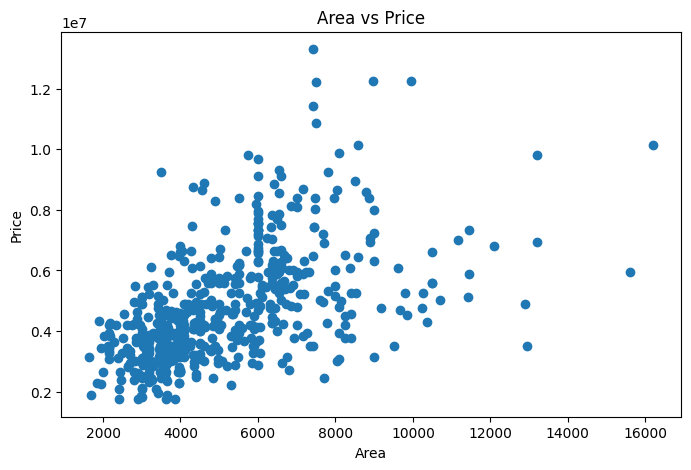

In [7]:
import matplotlib.pyplot as plt

# Titanic: Fare vs Survival
plt.figure(figsize=(8,5))
plt.scatter(titanic["Fare"], titanic["Survived"])
plt.title("Fare vs Survival")
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.show()

# Housing: Area vs Price
plt.figure(figsize=(8,5))
plt.scatter(housing["area"], housing["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## Correlation Analysis Results

### Titanic Dataset

- Fare has a positive correlation with survival.
- Passenger class (Pclass) has a negative correlation with survival.
- Higher-class passengers were more likely to survive.
- Correlation does not prove that ticket fare directly caused survival.

### Housing Dataset

- Area shows a strong positive correlation with house price.
- Bathrooms and stories also have positive correlations with price.
- Larger houses generally cost more.
- Correlation alone cannot prove that increasing area directly causes higher prices because other factors may influence price.

# Conclusion

The statistical analysis revealed important patterns in both datasets.

### Titanic Dataset
- Average passenger age was approximately 29 years.
- Fare positively influenced survival probability.
- Passenger class was strongly associated with survival outcomes.

### Housing Dataset
- Average house price was approximately 4.77 million.
- House area had the strongest positive relationship with price.
- Bathrooms and stories also contributed to higher prices.

Overall, descriptive statistics, probability distributions, hypothesis testing, and correlation analysis provided valuable insights into both datasets.